# Notebook 3 — RNN: Feature Extraction, Preprocessing & Training

## 1 Setup

In [1]:
import sys
print(sys.executable)
print(sys.path)
%pip install pandas matplotlib numpy tensorflow nltk ipykernel

import os
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CUDNN_USE_AUTOTUNE'] = '0'

%load_ext autoreload
%autoreload 2

/home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/.venv/bin/python
['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/.venv/lib/python3.12/site-packages']
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json, random, sys, time

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.wajib.rnn.RNN
from src.wajib.rnn.RNN import buildRNNKeras, trainRNNKeras, trainRNNDataset, RNNScratch
from src.wajib.shared.layers import EmbeddingLayer, DenseLayer
from src.wajib.shared.preprocessing import (
    loadFlickr8kCaptions, buildVocabulary, saveVocabulary, loadVocabulary,
)
from src.wajib.shared.decoder import greedyDecode
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print("GPUs:", gpus)

I0000 00:00:1778822452.509394  406209 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 Config

In [3]:
FEATURES_NPY  = PROJECT_ROOT / "src/wajib/weights/features/flickr8k_features.npy"
FEATURES_IDX  = PROJECT_ROOT / "src/wajib/weights/features/flickr8k_index.json"
CAPTIONS_FILE = PROJECT_ROOT / "data/flickr8k/captions.txt"
VOCAB_PATH    = PROJECT_ROOT / "src/wajib/weights/vocab.json"
WEIGHTS_DIR   = PROJECT_ROOT / "src/wajib/weights/rnn"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

EMBED_DIM    = 256
MAX_LEN      = 30
EPOCHS       = 5
BATCH_SIZE   = 64
CNN_FEAT_DIM = 2048

# 3 variasi num_layers × 2 variasi hidden_dim = 6 total
VARIATIONS = [
    (1, 128),
    (1, 512),
    (2, 128),
    (2, 512),
    (3, 128),
    (3, 512),
]

### 3 Load CNN Features

In [4]:
features_matrix = np.load(FEATURES_NPY)
with open(FEATURES_IDX) as f:
    idx_names = json.load(f)

image_features = {name: features_matrix[i] for i, name in enumerate(idx_names)}
print(f"Loaded {len(image_features)} features, dim={features_matrix.shape[1]}")

Loaded 8091 features, dim=2048


### 4 Load Captions + Split + Vocab

In [5]:
captions_dict = loadFlickr8kCaptions(str(CAPTIONS_FILE))

all_images = list(captions_dict.keys())
random.shuffle(all_images)  # seed already set in cell 1

train_imgs = set(all_images[:6000])
val_imgs   = set(all_images[6000:7000])
test_imgs  = set(all_images[7000:])

train_caps = {k: v for k, v in captions_dict.items() if k in train_imgs}
val_caps   = {k: v for k, v in captions_dict.items() if k in val_imgs}
test_caps  = {k: v for k, v in captions_dict.items() if k in test_imgs}

print(f"Split => train={len(train_caps)}, val={len(val_caps)}, test={len(test_caps)}")

if VOCAB_PATH.exists():
    vocab = loadVocabulary(str(VOCAB_PATH))
    print(f"Vocab loaded: {len(vocab)}")
else:
    all_train_caps = [cap for caps in train_caps.values() for cap in caps]
    vocab = buildVocabulary(all_train_caps, min_freq=2)
    saveVocabulary(vocab, str(VOCAB_PATH))
    print(f"Vocab built + saved: {len(vocab)}")

Split => train=6000, val=1000, test=1091
Vocab loaded: 4558


### 5 Build Dataset Arrays

In [6]:
X_cnn_tr, X_tok_tr, y_tr = trainRNNDataset(image_features, train_caps, vocab, MAX_LEN)
X_cnn_va, X_tok_va, y_va = trainRNNDataset(image_features, val_caps,   vocab, MAX_LEN)

print(f"Train -> X_cnn={X_cnn_tr.shape}, X_tok={X_tok_tr.shape}, y={y_tr.shape}")
print(f"Val   -> X_cnn={X_cnn_va.shape}, X_tok={X_tok_va.shape}, y={y_va.shape}")

Train -> X_cnn=(30000, 2048), X_tok=(30000, 30), y=(30000, 31)
Val   -> X_cnn=(5000, 2048), X_tok=(5000, 30), y=(5000, 31)


### 6 Training (6 Variation)

In [7]:
histories = {}

for num_layers, hidden_dim in VARIATIONS:
    name      = f"rnn_{num_layers}L_{hidden_dim}h"
    save_path = WEIGHTS_DIR / f"{name}.keras"

    print(f"\n{'='*50}\n  {name}\n{'='*50}")

    model = buildRNNKeras(
        vocab_size     = len(vocab),
        embed_dim      = EMBED_DIM,
        hidden_dim     = hidden_dim,
        num_rnn_layers = num_layers,
        cnn_feature_dim= CNN_FEAT_DIM,
    )
    model.summary()

    hist = trainRNNKeras(
        model,
        X_cnn_tr, X_tok_tr, y_tr,
        X_cnn_va, X_tok_va, y_va,
        epochs     = EPOCHS,
        batch_size = BATCH_SIZE,
        save_path  = str(save_path),
    )
    histories[name] = hist
    print(f"  Saved to {save_path.name}")

print(f"\nSemua {len(VARIATIONS)} variasi selesai.")


  rnn_1L_128h


I0000 00:00:1778822464.362201  406209 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1778822464.363340  406209 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2605 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_feature         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_feature[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,166,848 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, None, 1)   │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, None, 256) │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like           │ (None, 1, 256)    │          0 │ reshape[0][0]     │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, None, 256) │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, None, 256) │          0 │ ones_like[0][0],  │
│ (Concatenate)       │                   │            │ logical_or[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None, 256) │          0 │ reshape[0][0],    │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ (None, None, 128) │    197,120 │ concatenate[0][0… │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, None, 128) │          0 │ lstm_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, None,      │    587,982 │ dropout[0][0]     │
│                     │ 4558)             │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,476,494 (9.45 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_feature         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_proj (Dense)    │ (None, 256)       │    524,544 │ cnn_feature[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, None, 256) │  1,166,848 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, None)      │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 1, 256)    │          0 │ cnn_proj[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_5       │ (None, None, 1)   │          0 │ not_equal_5[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_5        │ (None, None, 256) │          0 │ embedding[0][0]   │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_5         │ (None, 1, 256)    │          0 │ reshape_5[0][0]   │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_5        │ (None, None, 256) │          0 │ expand_dims_5[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, None, 256) │          0 │ ones_like_5[0][0… │
│ (Concatenate)       │                   │            │ logical_or_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, None, 256) │          0 │ reshape_5[0][0],  │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_5 (Any)         │ (None, None)      │          0 │ concatenate_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_0 (LSTM)       │ (None, None, 512) │  1,574,912 │ concatenate_10[0… │
│                     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, None, 512) │          0 │ lstm_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, None, 512) │  2,099,200 │ dropout_9[0][0],  │
│                     │                   │            │ any_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, None, 512) │          0 │ lstm_1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, None, 512) │  2,099,200 │ dropout_10[0][0], │
│                     │                   │            │ any_5[0][0]     

 Total params: 9,802,958 (37.40 MB)

 Trainable params: 9,802,958 (37.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 104ms/step - loss: 4.7400 - val_loss: 4.1381
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - loss: 3.9589 - val_loss: 3.6599
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - loss: 3.5509 - val_loss: 3.3643
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - loss: 3.3140 - val_loss: 3.2254
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 104ms/step - loss: 3.1786 - val_loss: 3.1319
  Saved to rnn_3L_512h.keras

Semua 6 variasi selesai.


### Training and Loss Curve

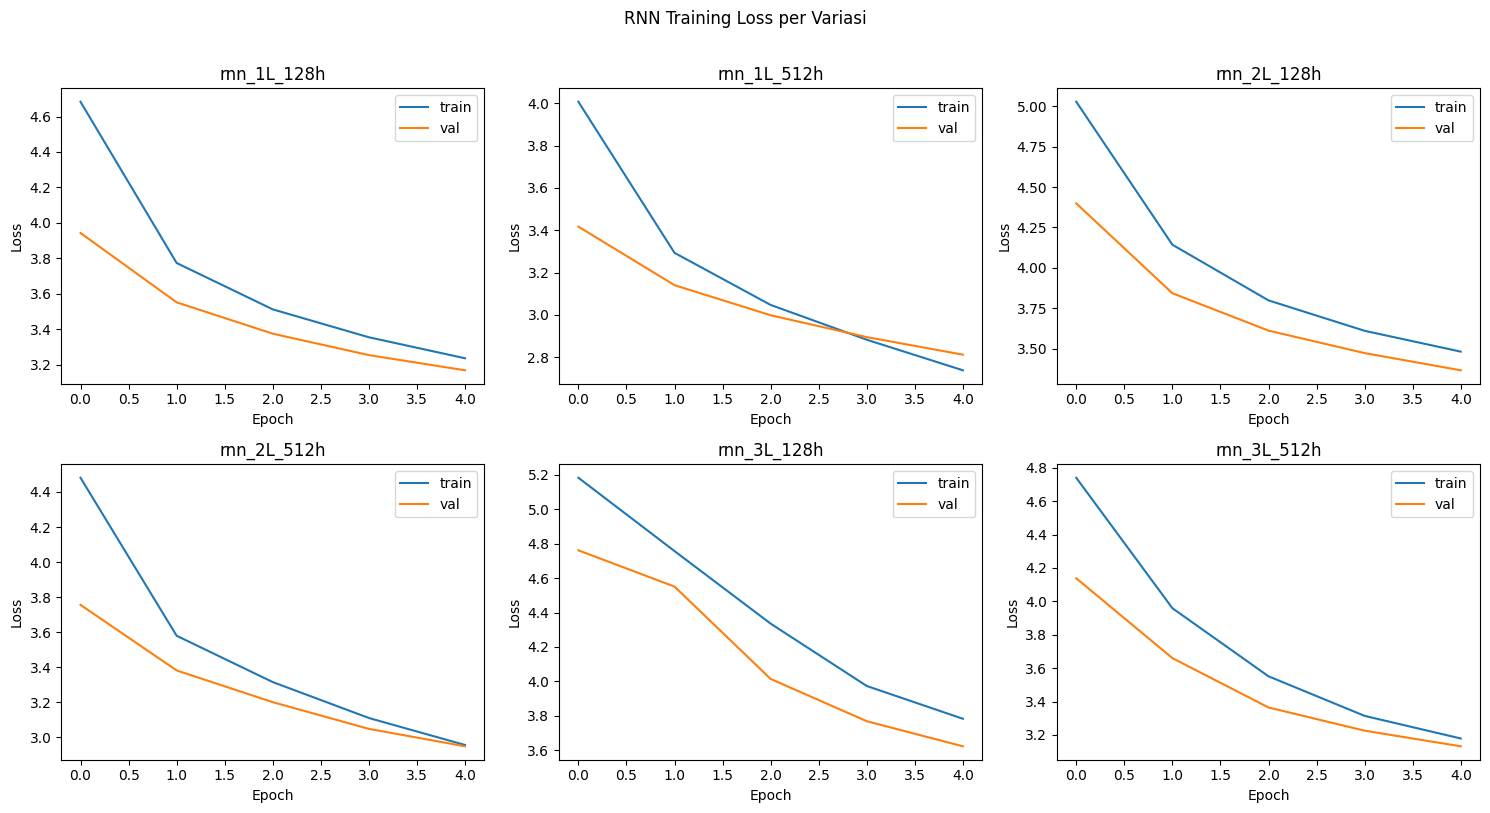

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (name, hist) in zip(axes.flatten(), histories.items()):
    ax.plot(hist['loss'],     label='train')
    ax.plot(hist['val_loss'], label='val')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle("RNN Training Loss per Variasi", y=1.01)
plt.tight_layout()
plt.savefig(WEIGHTS_DIR / "rnn_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### Training Summary

In [9]:
print(f"{'Model':<22} {'Best Val Loss':>14} {'Epochs':>7}")
print('-' * 45)
for name, hist in histories.items():
    print(f"{name:<22} {min(hist['val_loss']):>14.4f} {len(hist['val_loss']):>7}")

best_name   = min(histories, key=lambda n: min(histories[n]['val_loss']))
best_layers = int(best_name.split('L')[0].split('_')[1])
print(f"\nBest: {best_name}")

Model                   Best Val Loss  Epochs
---------------------------------------------
rnn_1L_128h                    3.1674       5
rnn_1L_512h                    2.8126       5
rnn_2L_128h                    3.3665       5
rnn_2L_512h                    2.9486       5
rnn_3L_128h                    3.6225       5
rnn_3L_512h                    3.1319       5

Best: rnn_1L_512h


In [10]:
def loadScratchFromKeras(model_path, num_layers):
    model = tf.keras.models.load_model(str(model_path))
    
    all_layer_names = [l.name for l in model.layers]
    
    if any('lstm' in name for name in all_layer_names):
        prefix = 'lstm'
    else:
        prefix = 'rnn'

    embed = EmbeddingLayer()
    embed.loadWeights(model.get_layer('embedding'))

    proj = DenseLayer()
    proj.loadWeights(model.get_layer('cnn_proj'))

    out = DenseLayer(activation='softmax')
    out.loadWeights(model.get_layer('output'))

    rnn = RNNScratch()
    rnn.loadWeights([model.get_layer(f'{prefix}_{i}') for i in range(num_layers)])

    return rnn, proj, embed, out

In [11]:
# Decode Testing (3 sampel)
import importlib
importlib.reload(src.wajib.rnn.RNN)
importlib.reload(src.wajib.shared.decoder)
best_path = WEIGHTS_DIR / f"{best_name}.keras"
rnn, proj, embed, out = loadScratchFromKeras(best_path, best_layers)

for img in list(val_caps.keys())[:3]:
    feat    = image_features[img]
    caption = ' '.join(greedyDecode(rnn, proj, embed, out, feat, vocab))
    gt      = val_caps[img][0]
    print(f"GT  : {gt}")
    print(f"Pred: {caption}")
    print()

GT  : a black dog leaps over a log
Pred: a dog is running through a grassy field

GT  : a man uses ice picks and crampons to scale ice
Pred: a man in a blue shirt is riding a bike on a dirt path

GT  : a man and a baby are in a yellow kayak on water
Pred: a man is climbing a rock face



## Analisis (BLEU-4)

In [12]:
results = {}

for num_layers, hidden_dim in VARIATIONS:
    name = f"rnn_{num_layers}L_{hidden_dim}h"
    path = WEIGHTS_DIR / f"{name}.keras"
    rnn, proj, embed, out = loadScratchFromKeras(path, num_layers)

    bleu_scores = []
    t0 = time.time()

    for img, caps in test_caps.items():
        if img not in image_features:
            continue
        hyp  = greedyDecode(rnn, proj, embed, out, image_features[img], vocab, MAX_LEN)
        refs = [cap.split() for cap in caps]
        bleu_scores.append(sentence_bleu(refs, hyp, weights=(0.25, 0.25, 0.25, 0.25)))

    elapsed = time.time() - t0
    results[name] = {'bleu4': np.mean(bleu_scores), 'time_s': elapsed,
                    'layers': num_layers, 'hidden': hidden_dim}
    print(f"{name:<22}  BLEU-4={results[name]['bleu4']:.4f}  time={elapsed:.1f}s")

/home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/.venv/lib/python3.12/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU

rnn_1L_128h             BLEU-4=0.0285  time=31.2s
rnn_1L_512h             BLEU-4=0.0518  time=199.3s
rnn_2L_128h             BLEU-4=0.0267  time=20.8s
rnn_2L_512h             BLEU-4=0.0426  time=238.0s
rnn_3L_128h             BLEU-4=0.0007  time=27.4s
rnn_3L_512h             BLEU-4=0.0422  time=362.2s


### Keras Greedy Decode for Best Model

In [ ]:
def kerasGreedyDecode(model, cnn_feat, vocab, max_len=MAX_LEN):
    id2word = {v: k for k, v in vocab.items()}
    tokens  = [vocab['<start>']]
    for _ in range(max_len):
        out_k = model.predict(
            [cnn_feat[np.newaxis], np.array([tokens])], verbose=0
        )
        nxt = int(np.argmax(out_k[0, -1]))
        if nxt == vocab['<end>']:
            break
        tokens.append(nxt)
    return [id2word.get(t, '<unk>') for t in tokens[1:]]

best_keras_model = tf.keras.models.load_model(str(WEIGHTS_DIR / f"{best_name}.keras"))
rnn, proj, embed, out = loadScratchFromKeras(WEIGHTS_DIR / f"{best_name}.keras", best_layers)

bleu_keras, bleu_scratch = [], []
t_keras = t_scratch = 0.0

for img, caps in test_caps.items():
    if img not in image_features:
        continue
    feat = image_features[img]
    refs = [cap.split() for cap in caps]

    t0 = time.time()
    hyp_k = kerasGreedyDecode(best_keras_model, feat, vocab)
    t_keras += time.time() - t0
    bleu_keras.append(sentence_bleu(refs, hyp_k, weights=(0.25, 0.25, 0.25, 0.25)))

    t0 = time.time()
    hyp_s = greedyDecode(rnn, proj, embed, out, feat, vocab, MAX_LEN)
    t_scratch += time.time() - t0
    bleu_scratch.append(sentence_bleu(refs, hyp_s, weights=(0.25, 0.25, 0.25, 0.25)))

print(f"Keras   BLEU-4={np.mean(bleu_keras):.4f}  total={t_keras:.1f}s")
print(f"Scratch BLEU-4={np.mean(bleu_scratch):.4f}  total={t_scratch:.1f}s")

### Max Caption Length Variation

In [ ]:
rnn, proj, embed, out = loadScratchFromKeras(WEIGHTS_DIR / f"{best_name}.keras", best_layers)

print(f"{'max_len':>8} {'BLEU-4':>10}")
print('-' * 20)

for ml in [15, 30, 50]:
    scores = [
        sentence_bleu(
            [cap.split() for cap in caps],
            greedyDecode(rnn, proj, embed, out, image_features[img], vocab, ml),
            weights=(0.25, 0.25, 0.25, 0.25)
        )
        for img, caps in test_caps.items()
        if img in image_features
    ]
    print(f"{ml:>8} {np.mean(scores):>10.4f}")

 max_len     BLEU-4
--------------------
      15     0.0000
      30     0.0000
      50     0.0000


# Final Results

In [ ]:
rows = []
for name, r in results.items():
    rows.append({
        "Model": name,
        "Layers": r["layers"],
        "Hidden": r["hidden"],
        "BLEU-4": round(r["bleu4"], 4),
        "Time(s)": round(r["time_s"], 1),
    })

df = pd.DataFrame(rows)

df = df.sort_values("BLEU-4", ascending=False)

print(df.to_string(index=False))

      Model  Layers  Hidden  BLEU-4  Time(s)
rnn_1L_128h       1     128     0.0     28.0
rnn_1L_512h       1     512     0.0    138.7
rnn_2L_128h       2     128     0.0     40.2
rnn_2L_512h       2     512     0.0    167.0
rnn_3L_128h       3     128     0.0     12.9
rnn_3L_512h       3     512     0.0    173.9
